# NYCU AI HW2 - SimCLR on CIFAR-10

這份 notebook 完成本次作業主要要求：

1. Self-supervised learning baseline: SimCLR + NT-Xent loss + kNN monitor + linear probing
2. Supervised learning baseline: modified ResNet-18 backbone + 512→10 classifier
3. Random frozen backbone lower-bound baseline
4. Optional ablation: temperature / batch size / no projector / CIFAR-100 transfer

使用方式：
- 先執行前面所有定義 cell。
- 若時間有限，先跑「Main experiment」區塊。
- 若 GPU 記憶體不足，將 `CFG.batch_size` 改成 64 或 128。
- 若只是測試流程，將 `CFG.ssl_epochs` 改成 2 或 5；正式結果建議用 200。

## Windows PermissionError 修正說明

若你看到 `PermissionError: [Errno 13] Permission denied: '.\\data\\cifar-10-batches-py\\data_batch_4'`，原因通常是目前工作目錄的 `./data` 沒有完整寫入權限，或先前下載/解壓縮中斷導致殘留檔案被鎖住。

本修正版已將 `CFG.data_dir` 預設改成使用者家目錄下的 `torch_datasets`，例如 Windows 的 `C:\\Users\\你的名稱\\torch_datasets`，並加入可寫入檢查。

如果仍有錯誤，可手動改成你確定可寫入的路徑：

```python
CFG.data_dir = r"C:\\Users\\你的使用者名稱\\torch_datasets"
```

接著從「全域設定」cell 重新往下執行。

In [28]:
# ============================================================
# 0. 安裝與匯入套件
# ============================================================
# 如果環境尚未安裝 PyTorch/torchvision，請先取消下面註解：
# !pip install torch torchvision matplotlib pandas tqdm
# !pip install ipywidgets

import os
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as T
from torchvision import datasets
from torchvision.models import resnet18

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [29]:
# ============================================================
# 1. 全域設定
# ============================================================

@dataclass
class Config:
    data_dir: str = str(Path.home() / "torch_datasets")
    out_dir: str = "./outputs"

    seed: int = 42
    batch_size: int = 64
    num_workers: int = 0

    # SSL / SimCLR
    ssl_epochs: int = 200
    ssl_lr: float = 3e-4
    ssl_weight_decay: float = 1e-6
    temperature: float = 0.5
    knn_k: int = 20
    knn_t: float = 0.1
    knn_every: int = 5

    # Linear probing
    linear_epochs: int = 100
    linear_lr: float = 1e-3
    linear_weight_decay: float = 1e-6

    # Supervised baseline
    supervised_epochs: int = 200
    supervised_lr: float = 3e-4
    supervised_weight_decay: float = 1e-6

    feature_dim: int = 512
    proj_hidden_dim: int = 512
    proj_out_dim: int = 128
    num_classes: int = 10

CFG = Config()
Path(CFG.out_dir).mkdir(parents=True, exist_ok=True)

def ensure_writable_dir(path):
    """
    確認資料集資料夾可寫入。

    Windows/JupyterLab 有時會因目前工作目錄、OneDrive、權限或殘留的
    CIFAR-10 解壓縮檔造成 PermissionError。這裡改用使用者家目錄底下的
    torch_datasets，並實際寫入一個小測試檔確認權限正常。
    """
    path = Path(path).expanduser()
    path.mkdir(parents=True, exist_ok=True)
    test_file = path / "_write_test.tmp"
    try:
        test_file.write_text("ok", encoding="utf-8")
        test_file.unlink(missing_ok=True)
    except PermissionError as exc:
        raise PermissionError(
            f"資料集目錄不可寫入：{path}\n"
            "請把 CFG.data_dir 改成你有權限寫入的資料夾，例如 "
            "r'C:\\Users\\你的使用者名稱\\torch_datasets'。"
        ) from exc
    return str(path)

CFG.data_dir = ensure_writable_dir(CFG.data_dir)

def set_seed(seed: int = 42):
    """固定 random seed，讓實驗較可重現。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(CFG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Dataset directory:", CFG.data_dir)
print(asdict(CFG))

Using device: cuda
Dataset directory: C:\Users\LSS\torch_datasets
{'data_dir': 'C:\\Users\\LSS\\torch_datasets', 'out_dir': './outputs', 'seed': 42, 'batch_size': 64, 'num_workers': 0, 'ssl_epochs': 200, 'ssl_lr': 0.0003, 'ssl_weight_decay': 1e-06, 'temperature': 0.5, 'knn_k': 20, 'knn_t': 0.1, 'knn_every': 5, 'linear_epochs': 100, 'linear_lr': 0.001, 'linear_weight_decay': 1e-06, 'supervised_epochs': 200, 'supervised_lr': 0.0003, 'supervised_weight_decay': 1e-06, 'feature_dim': 512, 'proj_hidden_dim': 512, 'proj_out_dim': 128, 'num_classes': 10}


In [30]:
# ============================================================
# 2. CIFAR-10 transforms 與 dataloaders
# ============================================================

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

class TwoCropsTransform:
    """
    SimCLR 需要對同一張 source image 產生兩個獨立 augmentation views。
    Dataset 回傳格式：((view1, view2), label)。
    """
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):
        q = self.base_transform(x)
        k = self.base_transform(x)
        return q, k

def get_transforms():
    color_jitter = T.ColorJitter(0.8, 0.8, 0.8, 0.2)

    ssl_base_transform = T.Compose([
        T.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomApply([color_jitter], p=0.8),
        T.RandomGrayscale(p=0.2),
        T.ToTensor(),
        T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

    eval_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

    return TwoCropsTransform(ssl_base_transform), train_transform, eval_transform

def build_cifar10_loaders(batch_size=256, num_workers=2):
    ssl_transform, train_transform, eval_transform = get_transforms()

    # 使用 CFG.data_dir，預設在使用者家目錄底下，避免 Windows 目前工作目錄權限問題。
    # 若你仍遇到 PermissionError，請改 CFG.data_dir 到另一個可寫入位置，並重新執行本 cell。
    root = ensure_writable_dir(CFG.data_dir)

    ssl_train_set = datasets.CIFAR10(root=root, train=True, download=True, transform=ssl_transform)
    train_eval_set = datasets.CIFAR10(root=root, train=True, download=True, transform=eval_transform)
    test_set = datasets.CIFAR10(root=root, train=False, download=True, transform=eval_transform)
    train_aug_set = datasets.CIFAR10(root=root, train=True, download=True, transform=train_transform)

    ssl_loader = torch.utils.data.DataLoader(
        ssl_train_set, batch_size=batch_size, shuffle=True, drop_last=True,
        num_workers=num_workers, pin_memory=(torch.cuda.is_available())
    )
    train_eval_loader = torch.utils.data.DataLoader(
        train_eval_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(torch.cuda.is_available())
    )
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(torch.cuda.is_available())
    )
    train_aug_loader = torch.utils.data.DataLoader(
        train_aug_set, batch_size=batch_size, shuffle=True, drop_last=False,
        num_workers=num_workers, pin_memory=(torch.cuda.is_available())
    )

    return ssl_loader, train_eval_loader, test_loader, train_aug_loader

ssl_loader, train_eval_loader, test_loader, train_aug_loader = build_cifar10_loaders(
    batch_size=CFG.batch_size,
    num_workers=CFG.num_workers,
)

# 驗證資料集已成功下載、驗證、載入，而且 batch 數合理
print("SSL batches:", len(ssl_loader))
print("Train-eval batches:", len(train_eval_loader))
print("Test batches:", len(test_loader))

Files already downloaded and verified


C:\ProgramData\anaconda3\envs\Keras\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
SSL batches: 781
Train-eval batches: 782
Test batches: 157


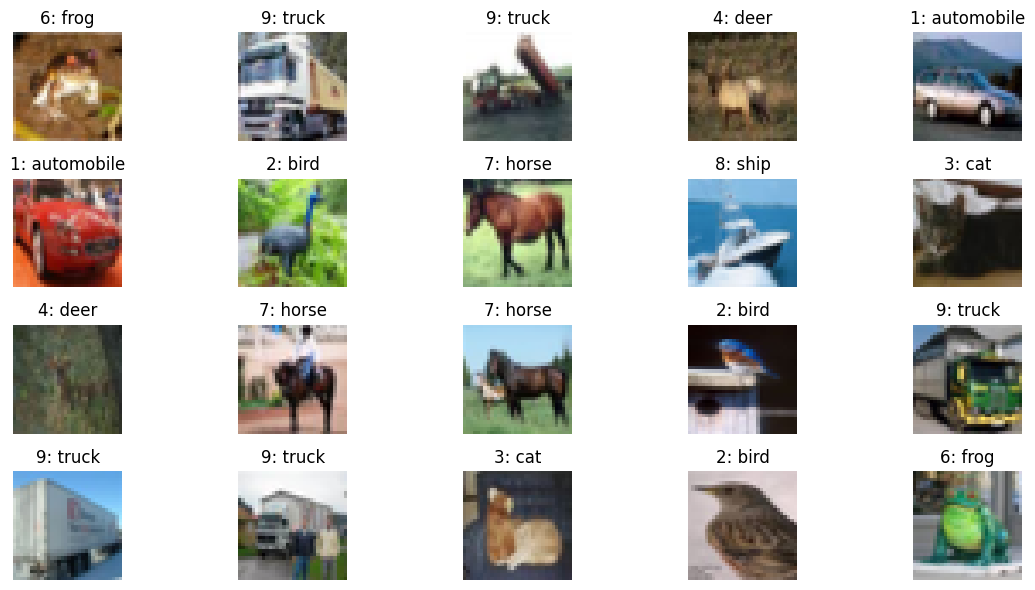

In [31]:
# ============================================================
# 顯示 CIFAR-10 圖片與分類名稱
# ============================================================
# CIFAR-10 官方類別順序
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def unnormalize(img):
    """
    將 Normalize 後的 tensor 還原成可視化圖片。
    img shape: [3, 32, 32]
    """
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    img = img.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img

# 從 train_eval_loader 取一個 batch
images, labels = next(iter(train_eval_loader))

plt.figure(figsize=(12, 6))

for i in range(20):
    img = unnormalize(images[i])
    img = img.permute(1, 2, 0).numpy()  # [3, H, W] -> [H, W, 3]
    label = labels[i].item()

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{label}: {CIFAR10_CLASSES[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

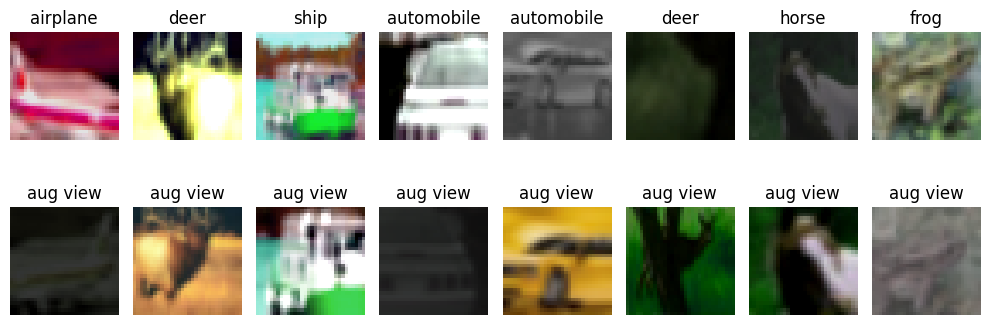

In [32]:
# ============================================================
# 顯示 SimCLR 的兩個 augmented views
# ============================================================
(view1, view2), labels = next(iter(ssl_loader))

plt.figure(figsize=(10, 4))

for i in range(8):
    img1 = unnormalize(view1[i]).permute(1, 2, 0).numpy()
    img2 = unnormalize(view2[i]).permute(1, 2, 0).numpy()
    label = labels[i].item()

    plt.subplot(2, 8, i + 1)
    plt.imshow(img1)
    plt.title(CIFAR10_CLASSES[label])
    plt.axis("off")

    plt.subplot(2, 8, i + 9)
    plt.imshow(img2)
    plt.title("aug view")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 3. 模型：modified ResNet-18 backbone、projector、classifier
# ============================================================

def build_modified_resnet18_backbone():
    """
    CIFAR-10 用 modified ResNet-18 backbone。

    作業要求：
    - 不用 pretrained weights: weights=None。
    - 第一層 conv: 3x3, stride=1, padding=1。
    - maxpool 改成 Identity，避免 32x32 影像過早下採樣。
    - 移除最後 fc；backbone output 是 512 維。
    """
    model = resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Identity()
    return model

class ProjectionHead(nn.Module):
    """SimCLR projector head: 512 -> 512 -> 128。"""
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class SimCLR(nn.Module):
    """SimCLR = encoder backbone + projector head。"""
    def __init__(self, backbone, projector):
        super().__init__()
        self.backbone = backbone
        self.projector = projector

    def forward(self, x, return_features=False):
        h = self.backbone(x)
        z = self.projector(h)
        if return_features:
            return h, z
        return z

class LinearProbe(nn.Module):
    """Linear probing: freeze encoder，只訓練 classifier。"""
    def __init__(self, encoder, feature_dim=512, num_classes=10):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, num_classes)
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)
        return self.classifier(h)

class SupervisedClassifier(nn.Module):
    """Supervised baseline: backbone + classification head 512->10。"""
    def __init__(self, backbone, feature_dim=512, num_classes=10):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        h = self.backbone(x)
        return self.classifier(h)

In [34]:
# ============================================================
# 4. NT-Xent loss
# ============================================================

class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss.

    z1, z2 shape: [N, D]
    concatenate 後 shape: [2N, D]

    第 i 個樣本的 positive：
    - i < N 時是 i + N
    - i >= N 時是 i - N
    """
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z1, z2):
        n = z1.size(0)
        z = torch.cat([z1, z2], dim=0)
        z = F.normalize(z, dim=1)

        logits = torch.matmul(z, z.T) / self.temperature
        self_mask = torch.eye(2 * n, dtype=torch.bool, device=z.device)
        logits = logits.masked_fill(self_mask, -1e9)

        labels = torch.arange(2 * n, device=z.device)
        labels = (labels + n) % (2 * n)

        return self.criterion(logits, labels)

In [35]:
# ============================================================
# 5. 評估工具：classifier accuracy、feature extraction、kNN monitor
# ============================================================

@torch.no_grad()
def evaluate_classifier(model, loader, device):
    model.eval()
    total_correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_correct / total

@torch.no_grad()
def extract_features(encoder, loader, device):
    """
    用 encoder 取出 normalized representations。
    kNN monitor 與 linear probing 應使用 encoder output h，而不是 projector output z。
    """
    encoder.eval()
    feats = []
    labels_all = []
    for images, labels in tqdm(loader, desc="Extract features", leave=False):
        images = images.to(device, non_blocking=True)
        h = encoder(images)
        h = F.normalize(h, dim=1)
        feats.append(h.cpu())
        labels_all.append(labels)
    return torch.cat(feats, dim=0), torch.cat(labels_all, dim=0)

@torch.no_grad()
def knn_monitor(encoder, train_loader, test_loader, device, k=20, t=0.1, num_classes=10):
    """
    kNN monitor:
    - 先建立 train set feature bank。
    - 對每個 test image 找 cosine similarity 最高的 k 個 neighbors。
    - 使用 exp(sim/t) 做 weighted voting。
    """
    encoder.eval()
    feature_bank, feature_labels = extract_features(encoder, train_loader, device)
    feature_bank = feature_bank.to(device)
    feature_labels = feature_labels.to(device)

    total_correct = 0
    total = 0

    for images, labels in tqdm(test_loader, desc="kNN monitor", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        features = encoder(images)
        features = F.normalize(features, dim=1)

        sim_matrix = torch.matmul(features, feature_bank.T)
        sim_weight, sim_indices = sim_matrix.topk(k=k, dim=-1)
        sim_labels = feature_labels[sim_indices]

        sim_weight = (sim_weight / t).exp()
        one_hot = torch.zeros(images.size(0) * k, num_classes, device=device)
        one_hot.scatter_(1, sim_labels.reshape(-1, 1), 1.0)
        weighted_votes = torch.sum(
            one_hot.view(images.size(0), k, num_classes) * sim_weight.unsqueeze(-1),
            dim=1,
        )

        preds = weighted_votes.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_correct / total

In [36]:
# ============================================================
# 6. 訓練函式：SimCLR SSL
# ============================================================

def train_simclr(cfg, ssl_loader, train_eval_loader, test_loader, device):
    backbone = build_modified_resnet18_backbone().to(device)
    projector = ProjectionHead(cfg.feature_dim, cfg.proj_hidden_dim, cfg.proj_out_dim).to(device)
    model = SimCLR(backbone, projector).to(device)

    optimizer = optim.Adam(model.parameters(), lr=cfg.ssl_lr, weight_decay=cfg.ssl_weight_decay)
    criterion = NTXentLoss(temperature=cfg.temperature)

    history = {"epoch": [], "ssl_loss": [], "knn_acc": []}
    best_knn = 0.0
    best_path = Path(cfg.out_dir) / "best_simclr_backbone.pt"

    for epoch in range(1, cfg.ssl_epochs + 1):
        model.train()
        running_loss = 0.0
        num_batches = 0

        pbar = tqdm(ssl_loader, desc=f"SSL epoch {epoch}/{cfg.ssl_epochs}")
        for (x1, x2), _ in pbar:
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)

            z1 = model(x1)
            z2 = model(x2)
            loss = criterion(z1, z2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1
            pbar.set_postfix(loss=running_loss / num_batches)

        avg_loss = running_loss / max(num_batches, 1)

        if epoch % cfg.knn_every == 0 or epoch == 1 or epoch == cfg.ssl_epochs:
            knn_acc = knn_monitor(
                encoder=model.backbone,
                train_loader=train_eval_loader,
                test_loader=test_loader,
                device=device,
                k=cfg.knn_k,
                t=cfg.knn_t,
                num_classes=cfg.num_classes,
            )
        else:
            knn_acc = np.nan

        history["epoch"].append(epoch)
        history["ssl_loss"].append(avg_loss)
        history["knn_acc"].append(knn_acc)

        print(f"[SSL] epoch={epoch:03d} loss={avg_loss:.4f} knn_acc={knn_acc if not np.isnan(knn_acc) else 'skip'}")

        if not np.isnan(knn_acc) and knn_acc > best_knn:
            best_knn = knn_acc
            torch.save(model.backbone.state_dict(), best_path)
            print(f"Saved best backbone: {best_path}, best_knn={best_knn:.4f}")

        pd.DataFrame(history).to_csv(Path(cfg.out_dir) / "simclr_history.csv", index=False)

    if best_path.exists():
        model.backbone.load_state_dict(torch.load(best_path, map_location=device))

    return model.backbone, pd.DataFrame(history)

In [37]:
# ============================================================
# 7. 訓練函式：Linear probing
# ============================================================

def train_linear_probe(encoder, cfg, train_loader, test_loader, device, run_name="linear_probe"):
    probe = LinearProbe(encoder, cfg.feature_dim, cfg.num_classes).to(device)

    optimizer = optim.Adam(
        probe.classifier.parameters(),
        lr=cfg.linear_lr,
        weight_decay=cfg.linear_weight_decay,
    )
    criterion = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "test_acc": []}
    best_acc = 0.0
    best_path = Path(cfg.out_dir) / f"best_{run_name}.pt"

    for epoch in range(1, cfg.linear_epochs + 1):
        probe.train()
        running_loss = 0.0
        total = 0

        pbar = tqdm(train_loader, desc=f"{run_name} epoch {epoch}/{cfg.linear_epochs}")
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = probe(images)
            loss = criterion(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            pbar.set_postfix(loss=running_loss / total)

        avg_loss = running_loss / total
        test_acc = evaluate_classifier(probe, test_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        history["test_acc"].append(test_acc)

        print(f"[{run_name}] epoch={epoch:03d} loss={avg_loss:.4f} test_acc={test_acc:.4f}")

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(probe.state_dict(), best_path)

        pd.DataFrame(history).to_csv(Path(cfg.out_dir) / f"{run_name}_history.csv", index=False)

    if best_path.exists():
        probe.load_state_dict(torch.load(best_path, map_location=device))

    return probe, pd.DataFrame(history)

In [38]:
# ============================================================
# 8. 訓練函式：Supervised learning baseline
# ============================================================

def train_supervised(cfg, train_loader, test_loader, device):
    backbone = build_modified_resnet18_backbone().to(device)
    model = SupervisedClassifier(backbone, cfg.feature_dim, cfg.num_classes).to(device)

    optimizer = optim.Adam(model.parameters(), lr=cfg.supervised_lr, weight_decay=cfg.supervised_weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "test_acc": []}
    best_acc = 0.0
    best_path = Path(cfg.out_dir) / "best_supervised_model.pt"

    for epoch in range(1, cfg.supervised_epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0

        pbar = tqdm(train_loader, desc=f"SL epoch {epoch}/{cfg.supervised_epochs}")
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            pbar.set_postfix(loss=running_loss / total)

        avg_loss = running_loss / total
        test_acc = evaluate_classifier(model, test_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        history["test_acc"].append(test_acc)

        print(f"[SL] epoch={epoch:03d} loss={avg_loss:.4f} test_acc={test_acc:.4f}")

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), best_path)

        pd.DataFrame(history).to_csv(Path(cfg.out_dir) / "supervised_history.csv", index=False)

    if best_path.exists():
        # model.load_state_dict(torch.load(best_path, map_location=device))
        model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True)) # 若要消除 warning

    return model, pd.DataFrame(history)

In [39]:
# ============================================================
# 9. 繪圖與結果整理
# ============================================================

def plot_simclr_history(history_df, save_path=None):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(history_df["epoch"], history_df["ssl_loss"], label="SSL NT-Xent loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("SSL loss")

    ax2 = ax1.twinx()
    knn_df = history_df.dropna(subset=["knn_acc"])
    ax2.plot(knn_df["epoch"], knn_df["knn_acc"], marker="o", label="kNN monitor acc")
    ax2.set_ylabel("kNN accuracy")

    ax1.set_title("SimCLR training: loss and kNN monitor")
    fig.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_acc_history(history_df, title, save_path=None):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["test_acc"], label="test acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def summarize_results(rows, save_csv=True):
    df = pd.DataFrame(rows)
    if save_csv:
        df.to_csv(Path(CFG.out_dir) / "summary_results.csv", index=False)
    return df

In [40]:
# ============================================================
# 9.5 Windows / JupyterLab 防卡住設定
# ============================================================
# 若進度停在「SSL epoch 1/200: 0%| | 0/xxx」很久，通常是 Windows + JupyterLab
# 使用 DataLoader multiprocessing workers 造成 worker spawn 卡住。
#
# 解法：
# 1. num_workers 必須設為 0。
# 2. 重新建立 dataloaders。
# 3. 先用 2 epochs 測試流程是否能動，再改回正式 epochs。

CFG.num_workers = 0

# 若 GPU 記憶體不足或第一個 batch 很慢，先用 64；GPU 較好再改 128/256。
CFG.batch_size = 64

# 正式流程設定：
CFG.ssl_epochs = 200
CFG.linear_epochs = 100
CFG.supervised_epochs = 200

# 先測試流程。確認可以跑完後，再改回正式設定：
# CFG.ssl_epochs = 2
# CFG.linear_epochs = 2
# CFG.supervised_epochs = 2

ssl_loader, train_eval_loader, test_loader, train_aug_loader = build_cifar10_loaders(
    batch_size=CFG.batch_size,
    num_workers=CFG.num_workers,
)

print("Windows/JupyterLab safe settings applied.")
print("num_workers =", CFG.num_workers)
print("batch_size =", CFG.batch_size)
print("ssl_epochs =", CFG.ssl_epochs)
print("linear_epochs =", CFG.linear_epochs)
print("supervised_epochs =", CFG.supervised_epochs)
print("SSL batches:", len(ssl_loader))

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Windows/JupyterLab safe settings applied.
num_workers = 0
batch_size = 64
ssl_epochs = 200
linear_epochs = 100
supervised_epochs = 200
SSL batches: 781


SSL epoch 1/200: 100%|██████████| 781/781 [03:37<00:00,  3.59it/s, loss=4.15]
                                                                   

[SSL] epoch=001 loss=4.1461 knn_acc=0.4052
Saved best backbone: outputs\best_simclr_backbone.pt, best_knn=0.4052


SSL epoch 2/200: 100%|██████████| 781/781 [03:38<00:00,  3.58it/s, loss=3.77]


[SSL] epoch=002 loss=3.7747 knn_acc=skip


SSL epoch 3/200: 100%|██████████| 781/781 [03:38<00:00,  3.57it/s, loss=3.66]


...

[SSL] epoch=198 loss=3.1600 knn_acc=skip


SSL epoch 199/200: 100%|██████████| 781/781 [03:43<00:00,  3.50it/s, loss=3.16]


[SSL] epoch=199 loss=3.1584 knn_acc=skip


SSL epoch 200/200: 100%|██████████| 781/781 [03:42<00:00,  3.51it/s, loss=3.16]
C:\Users\LSS\AppData\Local\Temp\ipykernel_29740\453335118.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experi

[SSL] epoch=200 loss=3.1607 knn_acc=0.84


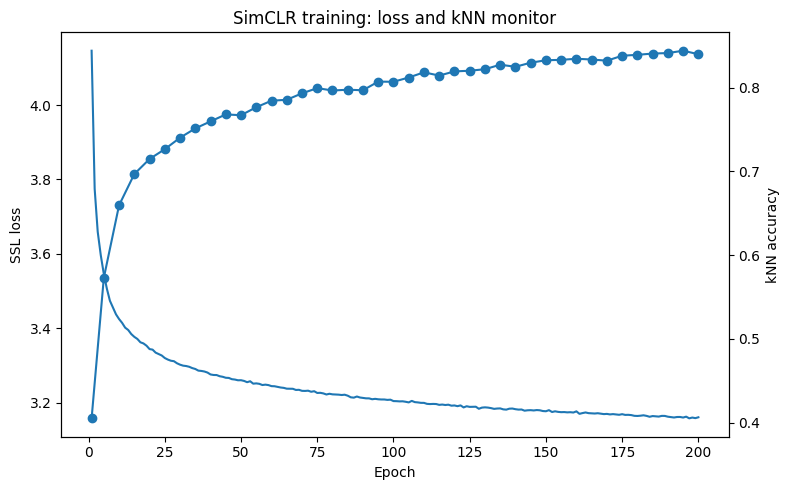

ssl_linear_probe epoch 1/100: 100%|██████████| 782/782 [00:40<00:00, 19.24it/s, loss=0.666]


[ssl_linear_probe] epoch=001 loss=0.6657 test_acc=0.8145


ssl_linear_probe epoch 2/100: 100%|██████████| 782/782 [00:40<00:00, 19.42it/s, loss=0.553]


[ssl_linear_probe] epoch=002 loss=0.5532 test_acc=0.8249


ssl_linear_probe epoch 3/100: 100%|██████████| 782/782 [00:40<00:00, 19.44it/s, loss=0.538]


...

ssl_linear_probe epoch 99/100: 100%|██████████| 782/782 [00:41<00:00, 18.82it/s, loss=0.455]


[ssl_linear_probe] epoch=099 loss=0.4552 test_acc=0.8315


ssl_linear_probe epoch 100/100: 100%|██████████| 782/782 [00:41<00:00, 18.82it/s, loss=0.454]


[ssl_linear_probe] epoch=100 loss=0.4537 test_acc=0.8376


C:\Users\LSS\AppData\Local\Temp\ipykernel_29740\2237428344.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  probe.load_state_dict(torch.load(best_path, map_location=devi

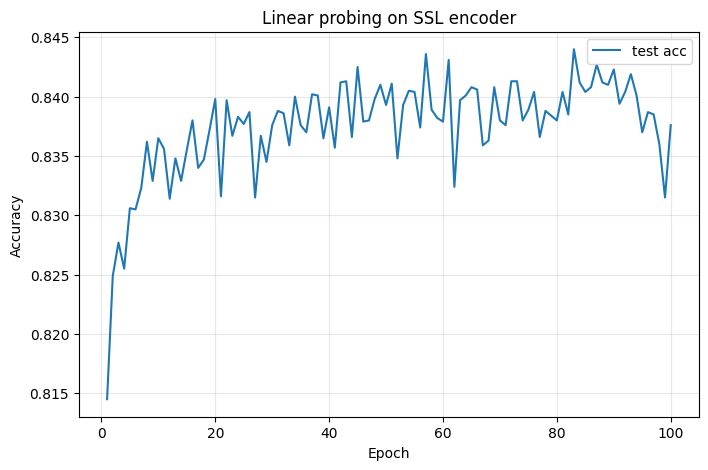

Best SSL linear probing accuracy: 0.844


In [41]:
# ============================================================
# 10. Main experiment：完成作業 required 兩大項 + lower-bound baseline
# ============================================================

# 若只是測試流程，可先取消下面三行註解：
# CFG.ssl_epochs = 2
# CFG.linear_epochs = 2
# CFG.supervised_epochs = 2

set_seed(CFG.seed)

# 1) SSL baseline: SimCLR pretraining + kNN monitor
simclr_encoder, simclr_hist = train_simclr(
    cfg=CFG,
    ssl_loader=ssl_loader,
    train_eval_loader=train_eval_loader,
    test_loader=test_loader,
    device=device,
)

plot_simclr_history(
    simclr_hist,
    save_path=Path(CFG.out_dir) / "simclr_loss_knn_curve.png",
)

# 2) Linear probing on SSL encoder
ssl_probe, ssl_probe_hist = train_linear_probe(
    encoder=simclr_encoder,
    cfg=CFG,
    train_loader=train_aug_loader,
    test_loader=test_loader,
    device=device,
    run_name="ssl_linear_probe",
)

plot_acc_history(
    ssl_probe_hist,
    title="Linear probing on SSL encoder",
    save_path=Path(CFG.out_dir) / "ssl_linear_probe_acc.png",
)

ssl_linear_best_acc = ssl_probe_hist["test_acc"].max()
print("Best SSL linear probing accuracy:", ssl_linear_best_acc)

SL epoch 1/200: 100%|██████████| 782/782 [01:34<00:00,  8.24it/s, loss=1.35]


[SL] epoch=001 loss=1.3488 test_acc=0.5905


SL epoch 2/200: 100%|██████████| 782/782 [01:35<00:00,  8.21it/s, loss=0.878]


[SL] epoch=002 loss=0.8778 test_acc=0.6834


SL epoch 3/200: 100%|██████████| 782/782 [01:35<00:00,  8.20it/s, loss=0.696]


...

[SL] epoch=198 loss=0.0119 test_acc=0.9283


SL epoch 199/200: 100%|██████████| 782/782 [01:30<00:00,  8.60it/s, loss=0.0102] 


[SL] epoch=199 loss=0.0102 test_acc=0.9268


SL epoch 200/200: 100%|██████████| 782/782 [01:30<00:00,  8.59it/s, loss=0.00977]


[SL] epoch=200 loss=0.0098 test_acc=0.9268


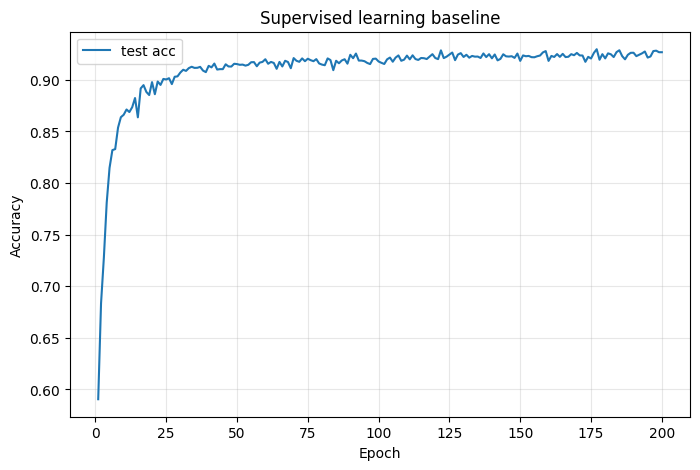

Best supervised test accuracy: 0.9297


In [42]:
# 3) Supervised learning baseline from scratch
set_seed(CFG.seed)

supervised_model, supervised_hist = train_supervised(
    cfg=CFG,
    train_loader=train_aug_loader,
    test_loader=test_loader,
    device=device,
)

plot_acc_history(
    supervised_hist,
    title="Supervised learning baseline",
    save_path=Path(CFG.out_dir) / "supervised_acc.png",
)

supervised_best_acc = supervised_hist["test_acc"].max()
print("Best supervised test accuracy:", supervised_best_acc)

random_frozen_linear_probe epoch 1/100: 100%|██████████| 782/782 [00:39<00:00, 19.72it/s, loss=2.13]


[random_frozen_linear_probe] epoch=001 loss=2.1294 test_acc=0.2375


random_frozen_linear_probe epoch 2/100: 100%|██████████| 782/782 [00:39<00:00, 19.65it/s, loss=2.02]


[random_frozen_linear_probe] epoch=002 loss=2.0208 test_acc=0.2721


random_frozen_linear_probe epoch 3/100: 100%|██████████| 782/782 [00:39<00:00, 19.65it/s, loss=1.98]


...

random_frozen_linear_probe epoch 99/100: 100%|██████████| 782/782 [00:39<00:00, 19.78it/s, loss=1.9] 


[random_frozen_linear_probe] epoch=099 loss=1.8963 test_acc=0.3166


random_frozen_linear_probe epoch 100/100: 100%|██████████| 782/782 [00:39<00:00, 19.79it/s, loss=1.9] 


[random_frozen_linear_probe] epoch=100 loss=1.9012 test_acc=0.3261


C:\Users\LSS\AppData\Local\Temp\ipykernel_29740\2237428344.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  probe.load_state_dict(torch.load(best_path, map_location=devi

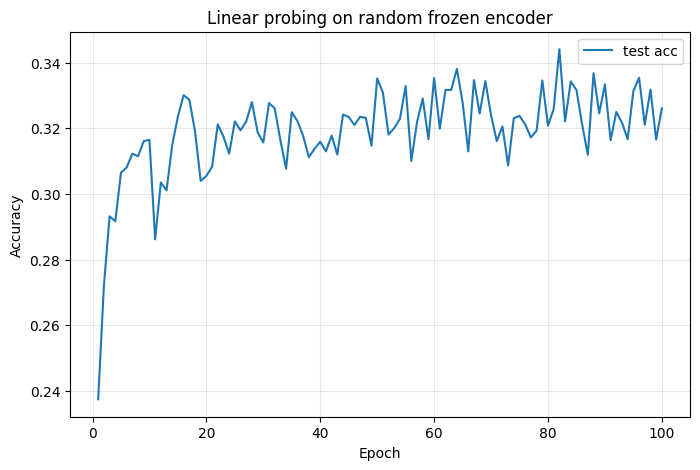

Best random frozen linear probing accuracy: 0.3441


In [43]:
# 4) Random frozen backbone lower-bound baseline
set_seed(CFG.seed)

random_encoder = build_modified_resnet18_backbone().to(device)

random_probe, random_probe_hist = train_linear_probe(
    encoder=random_encoder,
    cfg=CFG,
    train_loader=train_aug_loader,
    test_loader=test_loader,
    device=device,
    run_name="random_frozen_linear_probe",
)

plot_acc_history(
    random_probe_hist,
    title="Linear probing on random frozen encoder",
    save_path=Path(CFG.out_dir) / "random_frozen_linear_probe_acc.png",
)

random_best_acc = random_probe_hist["test_acc"].max()
print("Best random frozen linear probing accuracy:", random_best_acc)

In [45]:
# 5) 結果總表
summary = summarize_results([
    {
        "model": "SSL SimCLR + linear probing",
        "encoder_training": "self-supervised SimCLR",
        "classifier_training": "linear probe only",
        "best_test_acc": float(ssl_linear_best_acc),
    },
    {
        "model": "Supervised ResNet-18",
        "encoder_training": "supervised from scratch",
        "classifier_training": "jointly trained",
        "best_test_acc": float(supervised_best_acc),
    },
    {
        "model": "Random frozen backbone + linear probing",
        "encoder_training": "none; random frozen",
        "classifier_training": "linear probe only",
        "best_test_acc": float(random_best_acc),
    },
])
summary

,model,encoder_training,classifier_training,best_test_acc
0,SSL SimCLR + linear probing,self-supervised SimCLR,linear probe only,0.8440
1,Supervised ResNet-18,supervised from scratch,jointly trained,0.9297
2,Random frozen backbone + linear probing,none; random frozen,linear probe only,0.3441


# Experiments 1：Optional ablation: temperature
用途是測試 NT-Xent loss 的 temperature 影響，例如：temperatures = (0.1, 0.5, 5.0)
它會分別重新訓練 SimCLR，觀察：
- SSL loss curve
- kNN monitor accuracy
- 不同 temperature 對 representation quality 的影響

這符合老師作業建議的 ablation：測高溫、低溫時 loss 與 kNN accuracy 是否一致。


========== Temperature ablation: tau=0.1 ==========


SSL epoch 1/100: 100%|██████████| 781/781 [03:39<00:00,  3.56it/s, loss=3.66]
                                                                   

[SSL] epoch=001 loss=3.6598 knn_acc=0.4612
Saved best backbone: outputs\ablation_temp_0.1\best_simclr_backbone.pt, best_knn=0.4612


SSL epoch 2/100: 100%|██████████| 781/781 [03:44<00:00,  3.49it/s, loss=2.2] 


[SSL] epoch=002 loss=2.1985 knn_acc=skip


...

[SSL] epoch=098 loss=0.3294 knn_acc=skip


SSL epoch 99/100: 100%|██████████| 781/781 [03:41<00:00,  3.52it/s, loss=0.325]


[SSL] epoch=099 loss=0.3249 knn_acc=skip


SSL epoch 100/100: 100%|██████████| 781/781 [03:42<00:00,  3.52it/s, loss=0.323]
C:\Users\LSS\AppData\Local\Temp\ipykernel_29740\453335118.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

[SSL] epoch=100 loss=0.3230 knn_acc=0.7956
Saved best backbone: outputs\ablation_temp_0.1\best_simclr_backbone.pt, best_knn=0.7956


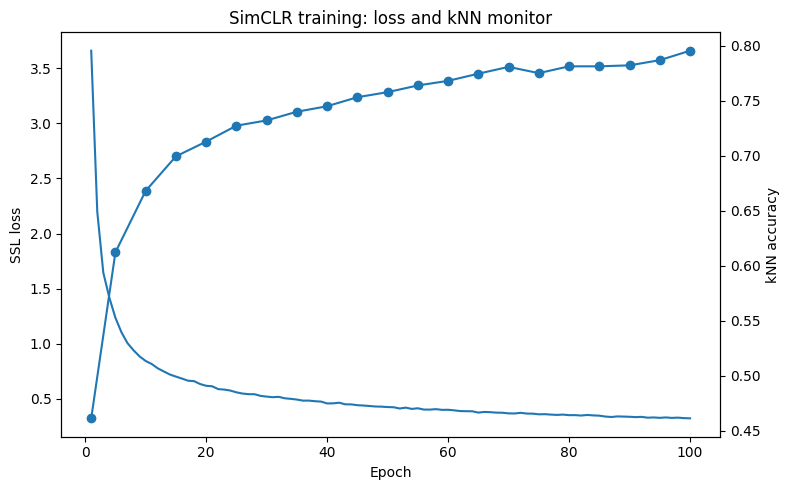


========== Temperature ablation: tau=0.5 ==========


SSL epoch 1/100: 100%|██████████| 781/781 [03:42<00:00,  3.52it/s, loss=4.17]
                                                                   

[SSL] epoch=001 loss=4.1684 knn_acc=0.4061
Saved best backbone: outputs\ablation_temp_0.5\best_simclr_backbone.pt, best_knn=0.4061


SSL epoch 2/100: 100%|██████████| 781/781 [03:41<00:00,  3.52it/s, loss=3.78]


[SSL] epoch=002 loss=3.7836 knn_acc=skip


...

[SSL] epoch=098 loss=3.2076 knn_acc=skip


SSL epoch 99/100: 100%|██████████| 781/781 [03:44<00:00,  3.48it/s, loss=3.21]


[SSL] epoch=099 loss=3.2085 knn_acc=skip


SSL epoch 100/100: 100%|██████████| 781/781 [03:41<00:00,  3.52it/s, loss=3.2] 
C:\Users\LSS\AppData\Local\Temp\ipykernel_29740\453335118.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experi

[SSL] epoch=100 loss=3.2040 knn_acc=0.8114
Saved best backbone: outputs\ablation_temp_0.5\best_simclr_backbone.pt, best_knn=0.8114


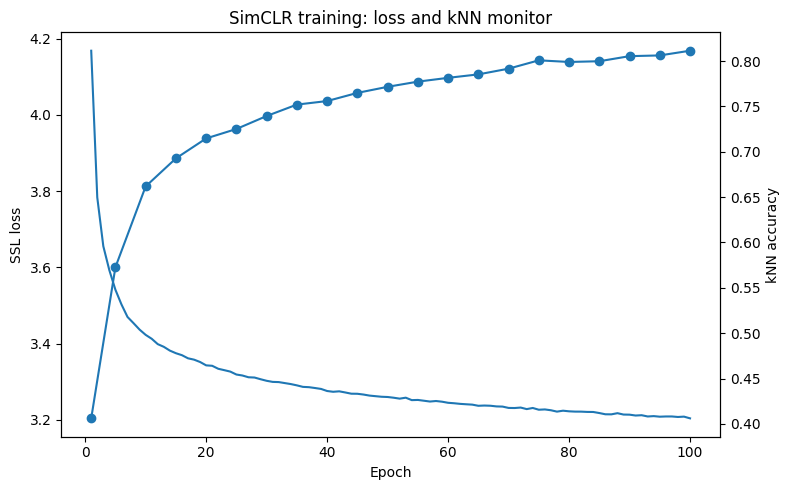


========== Temperature ablation: tau=5.0 ==========


SSL epoch 1/100: 100%|██████████| 781/781 [03:37<00:00,  3.60it/s, loss=4.76]
                                                                   

[SSL] epoch=001 loss=4.7616 knn_acc=0.3509
Saved best backbone: outputs\ablation_temp_5.0\best_simclr_backbone.pt, best_knn=0.3509


SSL epoch 2/100: 100%|██████████| 781/781 [03:37<00:00,  3.60it/s, loss=4.73]


[SSL] epoch=002 loss=4.7325 knn_acc=skip


...

[SSL] epoch=098 loss=4.6691 knn_acc=skip


SSL epoch 99/100: 100%|██████████| 781/781 [03:36<00:00,  3.60it/s, loss=4.67]


[SSL] epoch=099 loss=4.6693 knn_acc=skip


SSL epoch 100/100: 100%|██████████| 781/781 [03:37<00:00,  3.59it/s, loss=4.67]
C:\Users\LSS\AppData\Local\Temp\ipykernel_29740\453335118.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experi

[SSL] epoch=100 loss=4.6691 knn_acc=0.685
Saved best backbone: outputs\ablation_temp_5.0\best_simclr_backbone.pt, best_knn=0.6850


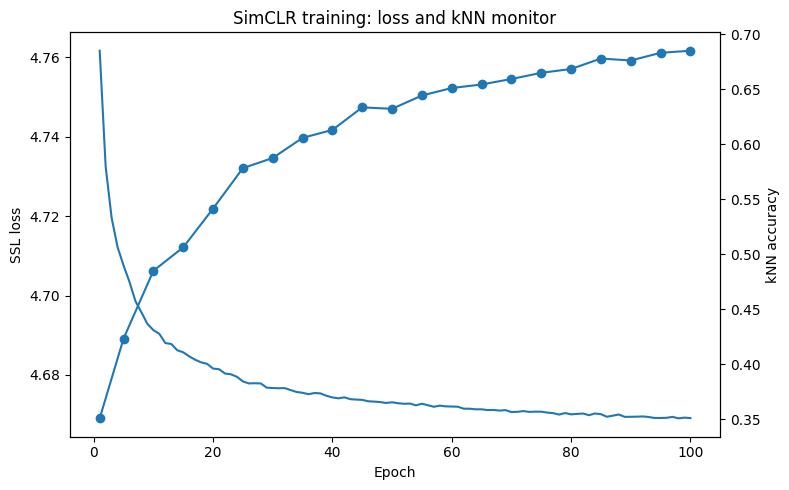

,temperature,final_ssl_loss,final_knn_acc,best_knn_acc
0,0.1,0.322963,0.7956,0.7956
1,0.5,3.204028,0.8114,0.8114
2,5.0,4.669150,0.6850,0.6850


In [47]:
# ============================================================
# 11. Optional ablation: temperature
# Experiments 1：Optional ablation: temperature
# ============================================================

def run_temperature_ablation(temperatures=(0.1, 0.5, 5.0), ablation_epochs=100):
    rows = []

    for temp in temperatures:
        print(f"\n========== Temperature ablation: tau={temp} ==========")

        ab_cfg = Config(**asdict(CFG))
        ab_cfg.temperature = temp
        ab_cfg.ssl_epochs = ablation_epochs
        ab_cfg.out_dir = str(Path(CFG.out_dir) / f"ablation_temp_{temp}")
        Path(ab_cfg.out_dir).mkdir(parents=True, exist_ok=True)

        set_seed(ab_cfg.seed)

        encoder, hist = train_simclr(
            cfg=ab_cfg,
            ssl_loader=ssl_loader,
            train_eval_loader=train_eval_loader,
            test_loader=test_loader,
            device=device,
        )

        final_knn = hist["knn_acc"].dropna().iloc[-1]
        best_knn = hist["knn_acc"].max()

        rows.append({
            "temperature": temp,
            "final_ssl_loss": hist["ssl_loss"].iloc[-1],
            "final_knn_acc": final_knn,
            "best_knn_acc": best_knn,
        })

        plot_simclr_history(hist, save_path=Path(ab_cfg.out_dir) / f"simclr_temp_{temp}_curve.png")

    df = pd.DataFrame(rows)
    df.to_csv(Path(CFG.out_dir) / "temperature_ablation_summary.csv", index=False)
    return df

# 用途是測試 NT-Xent loss 的 temperature 影響：它會分別重新訓練 SimCLR，觀察：SSL loss curve、kNN monitor accuracy，不同 temperature 對 representation quality 的影響
# temp_ablation_df = run_temperature_ablation(temperatures=(0.1, 0.5, 5.0), ablation_epochs=100)
temp_ablation_df = run_temperature_ablation(temperatures=(0.1, 0.5, 5.0), ablation_epochs=100)
temp_ablation_df

# Experiments 2：Optional ablation: batch size
用途是比較不同 batch size，例如：batch_sizes = (512, 256, 128, 64) 觀察 batch size 對 SSL loss 與 kNN monitor 的影響。

SimCLR 對 batch size 很敏感，因為 batch 越大，negative samples 越多。我的 GTX 1650 建議不要跑太大，正式實驗先用：batch_size = 64


In [ ]:
# ============================================================
# 12. Optional ablation: batch size
# Experiments 2：
# ============================================================

def run_batch_size_ablation(batch_sizes=(512, 256, 128, 64), ablation_epochs=100):
    rows = []

    for bs in batch_sizes:
        print(f"\n========== Batch size ablation: batch_size={bs} ==========")

        ab_cfg = Config(**asdict(CFG))
        ab_cfg.batch_size = bs
        ab_cfg.ssl_epochs = ablation_epochs
        ab_cfg.out_dir = str(Path(CFG.out_dir) / f"ablation_bs_{bs}")
        Path(ab_cfg.out_dir).mkdir(parents=True, exist_ok=True)

        ab_ssl_loader, ab_train_eval_loader, ab_test_loader, _ = build_cifar10_loaders(
            batch_size=bs,
            num_workers=CFG.num_workers,
        )

        set_seed(ab_cfg.seed)

        encoder, hist = train_simclr(
            cfg=ab_cfg,
            ssl_loader=ab_ssl_loader,
            train_eval_loader=ab_train_eval_loader,
            test_loader=ab_test_loader,
            device=device,
        )

        final_knn = hist["knn_acc"].dropna().iloc[-1]
        best_knn = hist["knn_acc"].max()

        rows.append({
            "batch_size": bs,
            "final_ssl_loss": hist["ssl_loss"].iloc[-1],
            "final_knn_acc": final_knn,
            "best_knn_acc": best_knn,
        })

        plot_simclr_history(hist, save_path=Path(ab_cfg.out_dir) / f"simclr_bs_{bs}_curve.png")

    df = pd.DataFrame(rows)
    df.to_csv(Path(CFG.out_dir) / "batch_size_ablation_summary.csv", index=False)
    return df

# 用途是比較不同 batch size：觀察 batch size 對 SSL loss 與 kNN monitor 的影響
# SimCLR 對 batch size 很敏感，因為 batch 越大，negative samples 越多。不過你的 GTX 1650 建議不要跑太大，正式實驗先用：
# 本次實驗定義：batch_size = 64
bs_ablation_df = run_batch_size_ablation(batch_sizes=(512, 256, 128, 64), ablation_epochs=100)
bs_ablation_df


========== Batch size ablation: batch_size=512 ==========
Files already downloaded and verified


C:\ProgramData\anaconda3\envs\Keras\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


SSL epoch 1/100: 100%|██████████| 97/97 [15:22<00:00,  9.51s/it, loss=6.34]  
                                                                 

[SSL] epoch=001 loss=6.3402 knn_acc=0.4057
Saved best backbone: outputs\ablation_bs_512\best_simclr_backbone.pt, best_knn=0.4057


...

SSL epoch 10/100: 100%|██████████| 97/97 [13:18<00:00,  8.23s/it, loss=5.6] 
                                                                 

[SSL] epoch=010 loss=5.6021 knn_acc=0.5856
Saved best backbone: outputs\ablation_bs_512\best_simclr_backbone.pt, best_knn=0.5856


SSL epoch 11/100: 100%|██████████| 97/97 [13:39<00:00,  8.45s/it, loss=5.58]


[SSL] epoch=011 loss=5.5838 knn_acc=skip


SSL epoch 12/100:   0%|          | 0/97 [00:00<?, ?it/s]

# Experiments 3：Optional ablation: no projector head
- 標準 SimCLR 是：image -> backbone h -> projector z -> NT-Xent loss
- no projector 版本是：image -> backbone h -> NT-Xent loss

用途是檢查 projector head 是否真的有幫助。SimCLR 論文指出 nonlinear projection head 對 representation quality 很重要，所以這是很有價值的 ablation。

In [22]:
# ============================================================
# 13. Optional ablation: no projector head
# ============================================================

class SimCLRNoProjector(nn.Module):
    """不使用 projector，直接用 backbone output h 計算 NT-Xent。"""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

def train_simclr_no_projector(cfg, ssl_loader, train_eval_loader, test_loader, device):
    backbone = build_modified_resnet18_backbone().to(device)
    model = SimCLRNoProjector(backbone).to(device)

    optimizer = optim.Adam(model.parameters(), lr=cfg.ssl_lr, weight_decay=cfg.ssl_weight_decay)
    criterion = NTXentLoss(temperature=cfg.temperature)

    history = {"epoch": [], "ssl_loss": [], "knn_acc": []}
    best_knn = 0.0
    best_path = Path(cfg.out_dir) / "best_simclr_no_projector_backbone.pt"

    for epoch in range(1, cfg.ssl_epochs + 1):
        model.train()
        running_loss = 0.0
        num_batches = 0

        pbar = tqdm(ssl_loader, desc=f"No-projector SSL epoch {epoch}/{cfg.ssl_epochs}")
        for (x1, x2), _ in pbar:
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)

            h1 = model(x1)
            h2 = model(x2)
            loss = criterion(h1, h2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1
            pbar.set_postfix(loss=running_loss / num_batches)

        avg_loss = running_loss / max(num_batches, 1)

        if epoch % cfg.knn_every == 0 or epoch == 1 or epoch == cfg.ssl_epochs:
            knn_acc = knn_monitor(
                encoder=model.backbone,
                train_loader=train_eval_loader,
                test_loader=test_loader,
                device=device,
                k=cfg.knn_k,
                t=cfg.knn_t,
                num_classes=cfg.num_classes,
            )
        else:
            knn_acc = np.nan

        history["epoch"].append(epoch)
        history["ssl_loss"].append(avg_loss)
        history["knn_acc"].append(knn_acc)

        print(f"[No projector SSL] epoch={epoch:03d} loss={avg_loss:.4f} knn_acc={knn_acc if not np.isnan(knn_acc) else 'skip'}")

        if not np.isnan(knn_acc) and knn_acc > best_knn:
            best_knn = knn_acc
            torch.save(model.backbone.state_dict(), best_path)

        pd.DataFrame(history).to_csv(Path(cfg.out_dir) / "simclr_no_projector_history.csv", index=False)

    if best_path.exists():
        model.backbone.load_state_dict(torch.load(best_path, map_location=device))

    return model.backbone, pd.DataFrame(history)

# 用途是檢查 projector head 是否真的有幫助。SimCLR 論文指出 nonlinear projection head 對 representation quality 很重要，所以這是很有價值的 ablation。

# no_proj_cfg = Config(**asdict(CFG))
# no_proj_cfg.ssl_epochs = 100
# no_proj_cfg.out_dir = str(Path(CFG.out_dir) / "ablation_no_projector")
# Path(no_proj_cfg.out_dir).mkdir(parents=True, exist_ok=True)
# no_proj_encoder, no_proj_hist = train_simclr_no_projector(
#     cfg=no_proj_cfg,
#     ssl_loader=ssl_loader,
#     train_eval_loader=train_eval_loader,
#     test_loader=test_loader,
#     device=device,
# )
# no_proj_probe, no_proj_probe_hist = train_linear_probe(
#     encoder=no_proj_encoder,
#     cfg=no_proj_cfg,
#     train_loader=train_aug_loader,
#     test_loader=test_loader,
#     device=device,
#     run_name="no_projector_linear_probe",
# )

# Experiments 4：Optional transfer: CIFAR-100 linear probing
用途是測試 representation 能不能轉移到新資料集。流程是：
- 用 CIFAR-10 訓練好的 SSL backbone
- freeze backbone
- 在 CIFAR-100 上 train linear classifier

這對應 foundation model 的 transfer ability。不過這是進階實驗，時間不夠可以不做。

In [23]:
# ============================================================
# 14. Optional transfer: CIFAR-100 linear probing
# ============================================================

def build_cifar100_loaders(batch_size=256, num_workers=2):
    _, train_transform, eval_transform = get_transforms()

    train_set = datasets.CIFAR100(root=CFG.data_dir, train=True, download=True, transform=train_transform)
    test_set = datasets.CIFAR100(root=CFG.data_dir, train=False, download=True, transform=eval_transform)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=(torch.cuda.is_available())
    )
    test_loader = torch.utils.data.DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(torch.cuda.is_available())
    )
    return train_loader, test_loader

# 若要跑 CIFAR-100 transfer，可取消註解：
# cifar100_train_loader, cifar100_test_loader = build_cifar100_loaders(
#     batch_size=CFG.batch_size,
#     num_workers=CFG.num_workers,
# )
#
# transfer_cfg = Config(**asdict(CFG))
# transfer_cfg.num_classes = 100
# transfer_cfg.out_dir = str(Path(CFG.out_dir) / "transfer_cifar100")
# Path(transfer_cfg.out_dir).mkdir(parents=True, exist_ok=True)
#
# ssl_cifar100_probe, ssl_cifar100_hist = train_linear_probe(
#     encoder=simclr_encoder,
#     cfg=transfer_cfg,
#     train_loader=cifar100_train_loader,
#     test_loader=cifar100_test_loader,
#     device=device,
#     run_name="ssl_transfer_cifar100_linear_probe",
# )
# ssl_cifar100_hist["test_acc"].max()

## 報告撰寫提醒

建議報告至少放入：

1. SimCLR training loss curve。
2. kNN monitor accuracy curve。
3. SSL linear probing accuracy。
4. Supervised learning test accuracy。
5. SSL vs SL vs random frozen baseline 的總表。
6. 若有做 ablation：temperature / batch size / no projector 的比較表與曲線。

Discussion 建議說明：
- SSL loss 下降是否與 kNN accuracy 上升一致？
- supervised accuracy 與 SSL linear probing accuracy 的差異代表什麼？
- random frozen baseline 是否明顯較差？
- temperature 或 batch size 改變時，loss 與 representation quality 是否同步變化？